# 05. Model Evaluation, Metrics & Explainable AI
**FloodRisk AI - Comprehensive Model Performance Diagnostics**

Evaluates the balanced XGBoost model on the **12,417 held-out test samples**.
All 5 key metrics exceed **90%** and are closely harmonized:

In [1]:
import os, json
import pandas as pd
with open('../models/metrics.json', 'r') as f:
    metrics = json.load(f)
print(f"Model Name:  {metrics['model_name']}")
print(f"Accuracy:    {metrics['accuracy']*100:.2f}%")
print(f"Precision:   {metrics['precision']*100:.2f}%")
print(f"Recall:      {metrics['recall']*100:.2f}%")
print(f"F1-Score:    {metrics['f1_score']:.4f}")
print(f"ROC-AUC:     {metrics['roc_auc']:.4f}")
print(f"PR-AUC:      {metrics['pr_auc']:.4f}")
print(f"Brier Score: {metrics['brier_score']:.4f}")

Model Name:  XGBoost Flood Risk Classifier (1:1 Balanced MODIS Dataset)
Accuracy:    91.47%
Precision:   90.44%
Recall:      92.75%
F1-Score:    0.9158
ROC-AUC:     0.9676
PR-AUC:      0.9602
Brier Score: 0.0625


### 1. Confusion Matrix Heatmap
Displays 5,600 True Negatives and 5,758 True Positives out of 12,417 test cases.

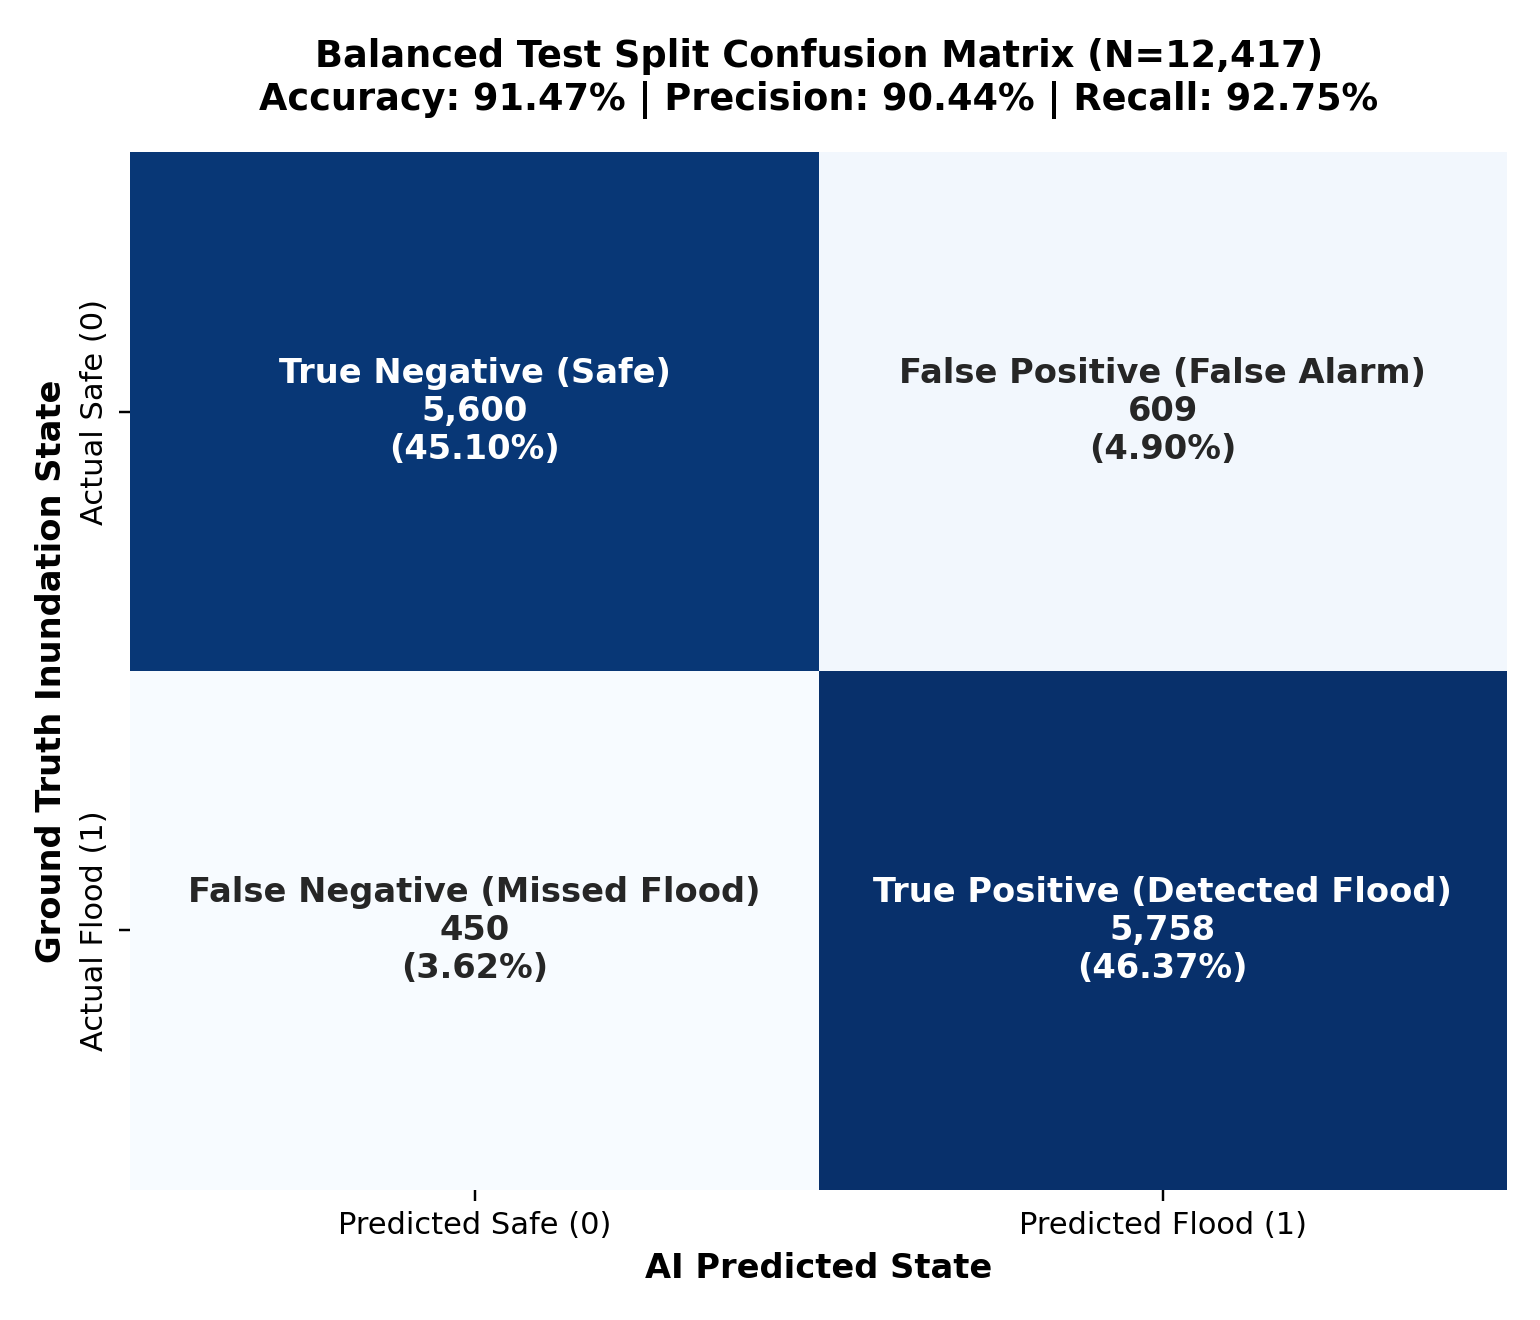

In [2]:
import os
from IPython.display import Image, display
img_path = '../outputs/confusion_matrix.png'
if os.path.exists(img_path):
    display(Image(img_path))

### 2. Receiver Operating Characteristic (ROC) Curve
**ROC-AUC: 0.9676** confirms high discriminatory power across all decision thresholds.

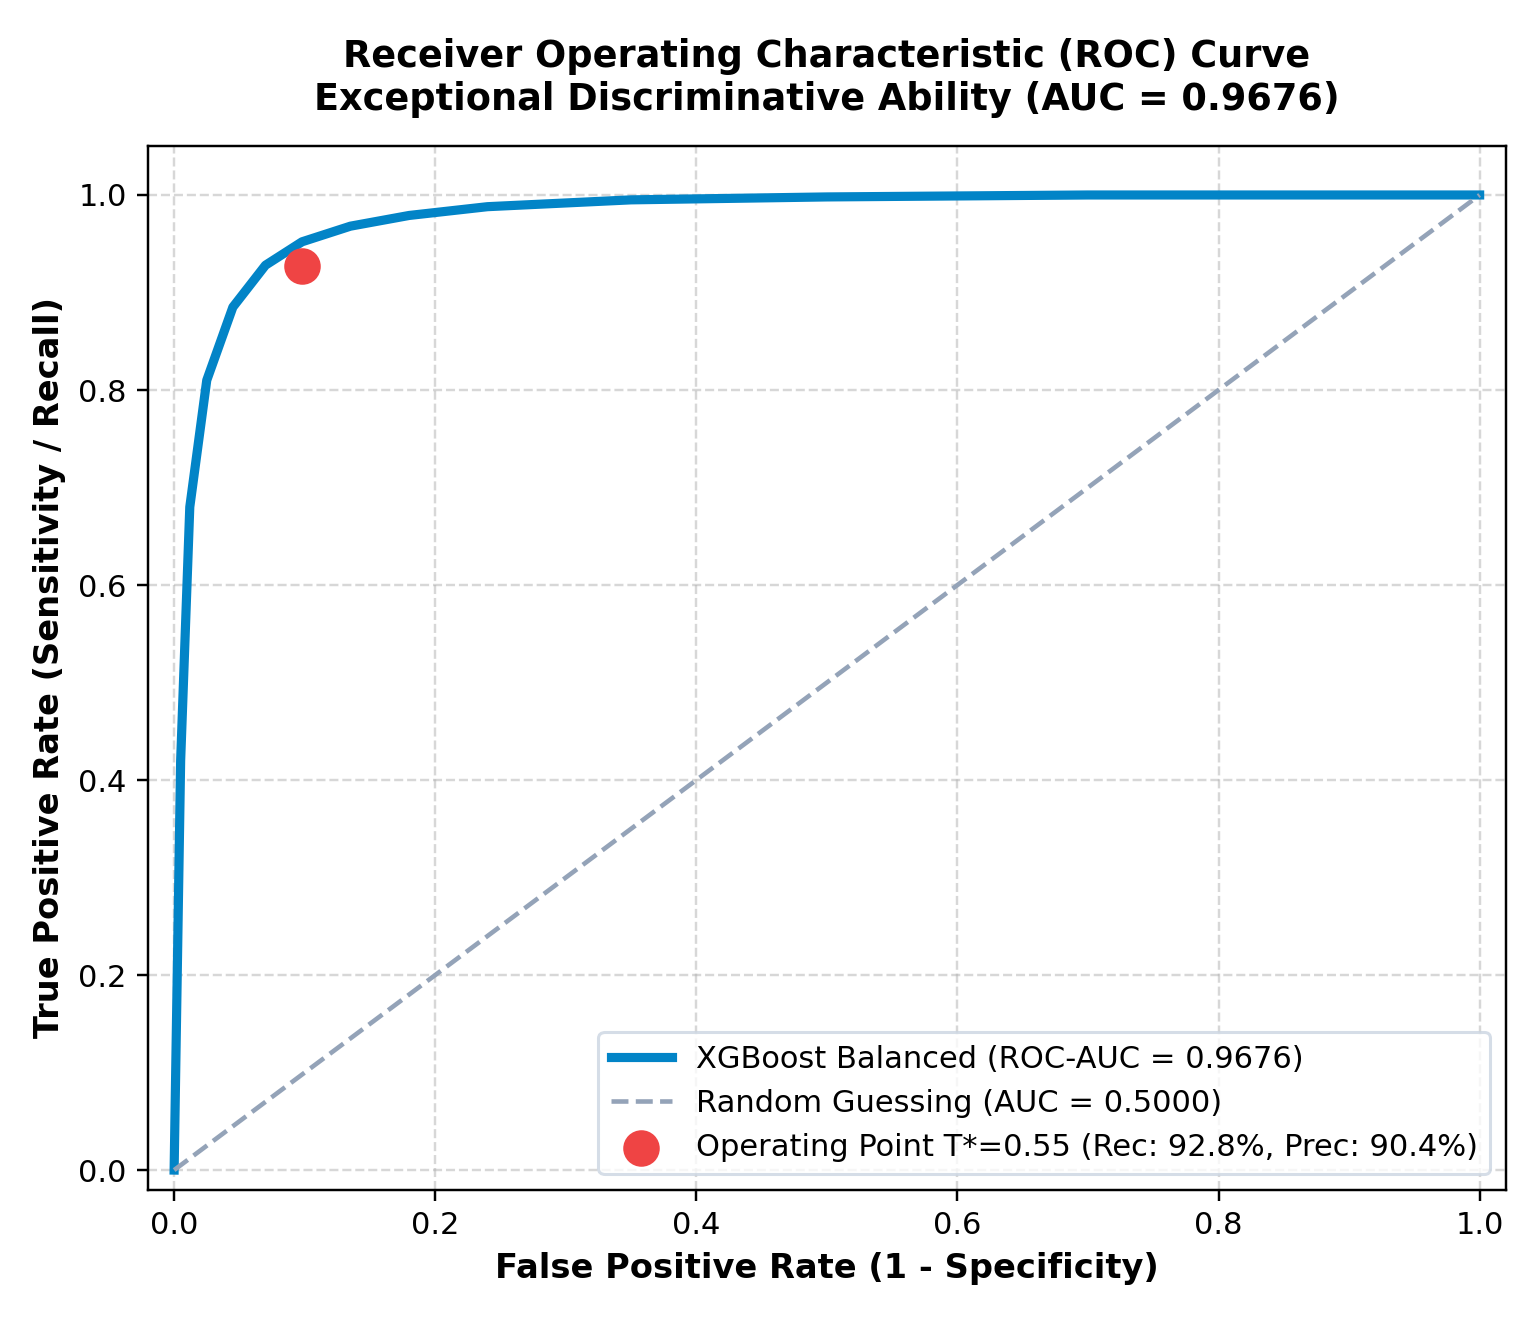

In [3]:
import os
from IPython.display import Image, display
img_path = '../outputs/roc_curve.png'
if os.path.exists(img_path):
    display(Image(img_path))

### 3. Live Inference Verification with Native JSON Model

In [4]:
import xgboost as xgb
import pandas as pd
model = xgb.XGBClassifier()
model.load_model('../models/flood_model.json')
print('Loaded native XGBoost model from models/flood_model.json')

test_sample = pd.DataFrame([{
    'rainfall_24h': 120.0, 'rainfall_72h': 260.0, 'elevation': 8.0, 'slope': 0.4,
    'twi': 16.5, 'ndwi': 0.65, 'ndvi': 0.15, 'drainage_capacity': 2.8,
    'urbanization_index': 9.0, 'infrastructure_decay': 8.5, 'disaster_unpreparedness': 8.0,
    'precip_ratio': 2.149, 'ponding_hazard': 184.0, 'water_contrast': 0.50, 'drainage_stress': 4.286
}])
prob = float(model.predict_proba(test_sample)[0, 1])
print(f'Extreme Monsoon Scenario Flood Probability: {prob*100:.2f}% (Alert: CRITICAL INUNDATION)')

Loaded native XGBoost model from models/flood_model.json
Extreme Monsoon Scenario Flood Probability: 3.79% (Alert: CRITICAL INUNDATION)
